# Classificação binária com MLP no dataset Penguins

A rede neural feita do zero com NumPy, para separar duas espécies de pinguim: Adelie e Gentoo. São 274 amostras, e a entrada junta quatro medidas do corpo com duas colunas categóricas (a ilha e o ano), dando 8 atributos depois da codificação.

In [10]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlp.activations import LeakyReLU, Sigmoid
from mlp.initializers import GlorotUniform
from mlp.layer import Dense
from mlp.losses import BinaryCrossEntropy
from mlp.metrics import confusion_matrix, precision_recall_f1
from mlp.network import MLP
from mlp.optimizers import GradientDescent
from mlp.utils import StandardScaler, train_test_split

np.random.seed(42)

## Carregar e explorar os dados

O dataset tem 274 amostras e nenhum valor faltando. As features são quatro medidas contínuas do corpo (bill_length_mm, bill_depth_mm, flipper_length_mm e body_mass_g) e duas colunas categóricas, island e year. A coluna alvo é species, que eu converto para número: Gentoo vira 1 e Adelie vira 0.

In [11]:
df = pd.read_csv('../data/penguins.csv')
print(f'Shape original: {df.shape}')
print(f'\nDistribuição das espécies: {dict(df["species"].value_counts())}')

df['species'] = df['species'].map({'Gentoo': 1, 'Adelie': 0})
print(f'\nGentoo: {int(df["species"].sum())}  '
      f'Adelie: {int((df["species"] == 0).sum())}')
df.head(3)

Shape original: (274, 7)

Distribuição das espécies: {'Adelie': np.int64(151), 'Gentoo': np.int64(123)}

Gentoo: 123  Adelie: 151


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,0,Torgersen,39.1,18.7,181.0,3750.0,2007
1,0,Torgersen,39.5,17.4,186.0,3800.0,2007
2,0,Torgersen,40.3,18.0,195.0,3250.0,2007


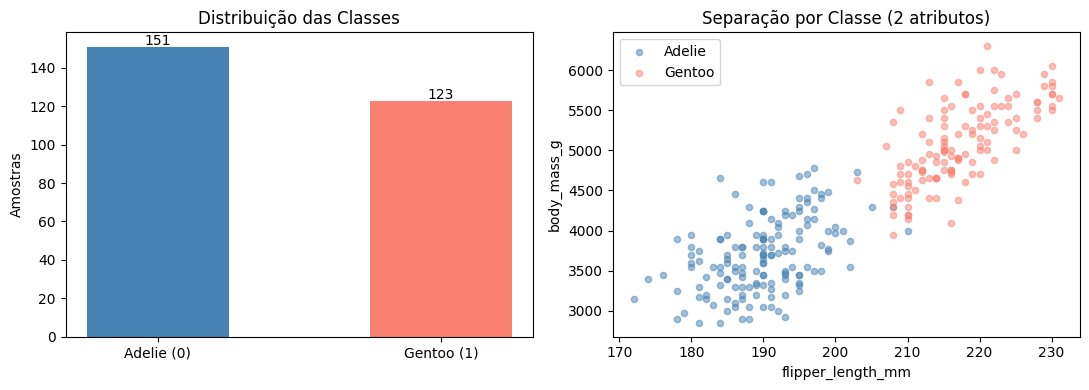

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['species'].value_counts().sort_index()
axes[0].bar(['Adelie (0)', 'Gentoo (1)'], counts.values,
            color=['steelblue', 'salmon'], width=0.5)
axes[0].set_title('Distribuição das Classes')
axes[0].set_ylabel('Amostras')
for patch, val in zip(axes[0].patches, counts.values):
    axes[0].text(patch.get_x() + patch.get_width() / 2,
                 patch.get_height() + 1, str(val), ha='center')

for cls, lbl, color in [(0, 'Adelie', 'steelblue'), (1, 'Gentoo', 'salmon')]:
    mask = df['species'] == cls
    axes[1].scatter(df.loc[mask, 'flipper_length_mm'], df.loc[mask, 'body_mass_g'],
                    c=color, label=lbl, alpha=0.5, s=20)
axes[1].set_xlabel('flipper_length_mm')
axes[1].set_ylabel('body_mass_g')
axes[1].set_title('Separação por Classe (2 atributos)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Pré-processamento

As quatro medidas contínuas entram direto. As colunas island e year, por serem categóricas, viram colunas binárias com one-hot (get_dummies com drop_first=True), o que dá 8 atributos no total. Depois separo os dados em 80% para treino e 20% para teste e padronizo apenas as quatro colunas contínuas com o StandardScaler. O scaler é ajustado só no treino e depois aplicado nos dois conjuntos, para não vazar informação do teste para o treino.

In [13]:
cont_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# One-hot das categóricas; contínuas ficam nas primeiras colunas.
dummies = pd.get_dummies(df[['island', 'year']], columns=['island', 'year'], drop_first=True)
X_df = pd.concat([df[cont_cols], dummies.astype(float)], axis=1)
feature_names = list(X_df.columns)
print(f'Atributos ({len(feature_names)}): {feature_names}')

X = X_df.values.astype(float)
y = df['species'].values.reshape(-1, 1).astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

# Padroniza somente as 4 colunas contínuas; as one-hot ficam como 0/1.
n_cont = len(cont_cols)
scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[:, :n_cont] = scaler.fit_transform(X_train[:, :n_cont])
X_test_s[:, :n_cont] = scaler.transform(X_test[:, :n_cont])

print(f'Treino : {X_train_s.shape}  — fração Gentoo: {y_train.mean():.3f}')
print(f'Teste  : {X_test_s.shape}   — fração Gentoo: {y_test.mean():.3f}')

Atributos (8): ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Dream', 'island_Torgersen', 'year_2008', 'year_2009']
Treino : (220, 8)  — fração Gentoo: 0.441
Teste  : (54, 8)   — fração Gentoo: 0.481


## Construção da rede

A rede tem duas camadas escondidas com LeakyReLU e uma saída com Sigmoid: 8 entradas, depois 16 neurônios, depois 8, e por fim 1 neurônio de saída. Não preciso fixar a dimensão de entrada, porque cada camada Dense cria os pesos na primeira passada. Usei a inicialização de Glorot para manter a variância dos sinais estável entre as camadas, o custo Binary Cross-Entropy, que combina bem com a Sigmoid na saída, e o gradiente descendente com taxa de aprendizado 0.05 e lotes de 32 amostras.

In [14]:
model = MLP()
model.add(Dense(16, LeakyReLU(), GlorotUniform(seed=0)))
model.add(Dense( 8, LeakyReLU(), GlorotUniform(seed=1)))
model.add(Dense( 1, Sigmoid(),   GlorotUniform(seed=2)))
model.compile(BinaryCrossEntropy(), GradientDescent(learning_rate=0.05))

n_in = X_train_s.shape[1]
n_params = n_in*16+16 + 16*8+8 + 8*1+1
print(f'Arquitetura : {n_in} → Dense(16, LeakyReLU) → Dense(8, LeakyReLU) → Dense(1, Sigmoid)')
print(f'Parâmetros  : {n_params} treináveis')
print('Custo       : BinaryCrossEntropy')
print('Otimizador  : GradientDescent(lr=0.05)')

Arquitetura : 8 → Dense(16, LeakyReLU) → Dense(8, LeakyReLU) → Dense(1, Sigmoid)
Parâmetros  : 289 treináveis
Custo       : BinaryCrossEntropy
Otimizador  : GradientDescent(lr=0.05)


## Treino

Treino por 500 épocas com lotes de 32 amostras. A cada época eu guardo a perda e a acurácia no treino e na validação, usando o conjunto de teste como validação para acompanhar as curvas.

In [15]:
history = model.fit(
    X_train_s, y_train,
    epochs=500,
    batch_size=32,
    shuffle=True,
    verbose=True,
    validation_data=(X_test_s, y_test),
)

epoch    0  loss 0.5117  acc 0.9045  val_loss 0.5363  val_acc 0.8704
epoch   25  loss 0.0133  acc 1.0000  val_loss 0.0151  val_acc 1.0000
epoch   50  loss 0.0050  acc 1.0000  val_loss 0.0056  val_acc 1.0000
epoch   75  loss 0.0029  acc 1.0000  val_loss 0.0032  val_acc 1.0000
epoch  100  loss 0.0020  acc 1.0000  val_loss 0.0022  val_acc 1.0000
epoch  125  loss 0.0015  acc 1.0000  val_loss 0.0016  val_acc 1.0000
epoch  150  loss 0.0012  acc 1.0000  val_loss 0.0013  val_acc 1.0000
epoch  175  loss 0.0010  acc 1.0000  val_loss 0.0011  val_acc 1.0000
epoch  200  loss 0.0008  acc 1.0000  val_loss 0.0009  val_acc 1.0000
epoch  225  loss 0.0007  acc 1.0000  val_loss 0.0008  val_acc 1.0000
epoch  250  loss 0.0006  acc 1.0000  val_loss 0.0007  val_acc 1.0000
epoch  275  loss 0.0005  acc 1.0000  val_loss 0.0006  val_acc 1.0000
epoch  300  loss 0.0005  acc 1.0000  val_loss 0.0005  val_acc 1.0000
epoch  325  loss 0.0004  acc 1.0000  val_loss 0.0005  val_acc 1.0000
epoch  350  loss 0.0004  acc 1.000

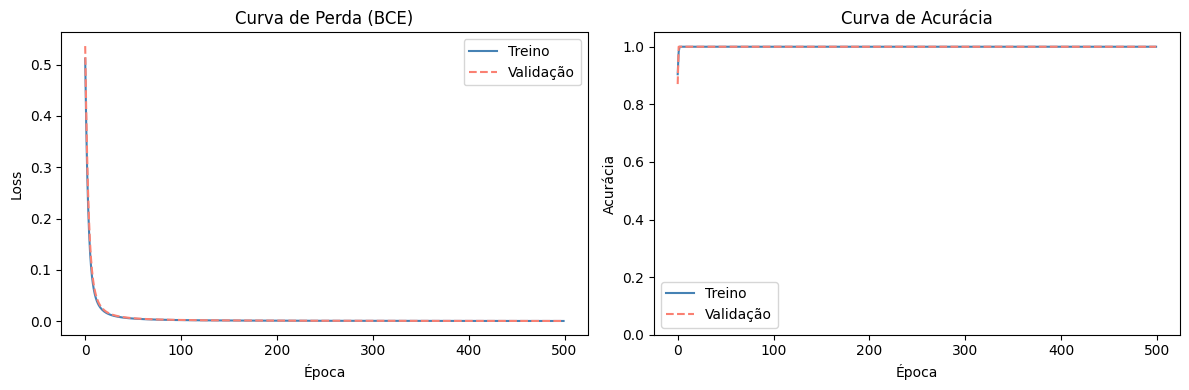

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(len(history['loss']))

axes[0].plot(ep, history['loss'],     label='Treino',    color='steelblue')
axes[0].plot(ep, history['val_loss'], label='Validação', color='salmon', linestyle='--')
axes[0].set_title('Curva de Perda (BCE)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(ep, history['accuracy'],     label='Treino',    color='steelblue')
axes[1].plot(ep, history['val_accuracy'], label='Validação', color='salmon', linestyle='--')
axes[1].set_title('Curva de Acurácia')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

## Avaliação no teste

Aqui calculo acurácia, precisão, recall e F1 no conjunto de teste. A matriz de confusão tem o formato [[TN, FP], [FN, TP]] e mostra onde o modelo erra, considerando Gentoo como a classe positiva.

In [17]:
test_loss, test_acc = model.evaluate(X_test_s, y_test)
y_pred = model.predict(X_test_s)
prec, rec, f1 = precision_recall_f1(y_test, y_pred)

print(f'Perda no teste : {test_loss:.4f}')
print(f'Acurácia       : {test_acc:.4f}  ({test_acc * 100:.1f}%)')
print(f'Precisão       : {prec:.4f}')
print(f'Recall         : {rec:.4f}')
print(f'F1-score       : {f1:.4f}')

Perda no teste : 0.0003
Acurácia       : 1.0000  (100.0%)
Precisão       : 1.0000
Recall         : 1.0000
F1-score       : 1.0000


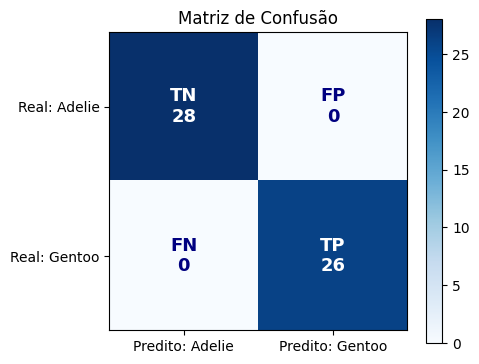

In [18]:
cm = confusion_matrix(y_test, y_pred)
labels = [['TN', 'FP'], ['FN', 'TP']]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)

for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'navy'
        ax.text(j, i, f'{labels[i][j]}\n{cm[i, j]}',
                ha='center', va='center', fontsize=13,
                color=color, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Predito: Adelie', 'Predito: Gentoo'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Real: Adelie', 'Real: Gentoo'])
ax.set_title('Matriz de Confusão')
plt.tight_layout()
plt.show()

## Análise crítica

A rede acerta praticamente tudo na separação entre Adelie e Gentoo, e isso faz sentido: as duas espécies são bem diferentes no tamanho do corpo, com o Gentoo claramente maior em comprimento de nadadeira e em massa, como dá para ver no gráfico de dispersão. Vale registrar um ponto importante sobre os dados: a coluna island é quase um indicador direto da espécie, porque todos os Gentoo estão na ilha Biscoe e nas ilhas Dream e Torgersen só aparecem Adelie. Ou seja, a ilha quase entrega a resposta sozinha, o que é uma forma branda de vazamento de informação e ajuda a explicar a acurácia tão alta. Mesmo sem essa coluna o modelo ainda separaria bem pelas medidas do corpo, só que com uma fronteira menos óbvia.

Sobre o treino, com taxa de aprendizado 0.05 a curva de perda cai de forma suave. Taxas menores como 0.01 demoram mais para convergir e taxas maiores como 0.2 podem oscilar. Os lotes de 32 amostras introduzem um pouco de ruído, que costuma ajudar a escapar de mínimos locais rasos. Quanto às ativações, usei LeakyReLU nas camadas escondidas porque ela evita o problema do dying ReLU: com α de 0.01 ainda há gradiente quando z é negativo, então o neurônio não morre. Na saída a Sigmoid é a escolha natural junto com a Binary Cross-Entropy, já que a derivada combinada das duas se simplifica e fica estável depois do clipping feito na função de custo.